# TECH 405 — Week 4 Assignment
## Neural Network Implementation, Hyperparameter Tuning, and Evaluation

**Project:** AI Based Vegetable and Fruit Freshness Detection Using CNN
**Dataset:** [Fruits and Vegetables dataset](https://www.kaggle.com/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset) by Muhriddin Mukhiddinov (Kaggle), selected and explored in the Week 2 assignment
**Student:** Chris
**Supervisor:** Prof. Bibek Khanal

### Objective
This notebook implements a Convolutional Neural Network (CNN) that classifies produce images as
fresh or rotten, builds on the data pipeline established in the Week 2 EDA notebook, adjusts
hyperparameters and observes the effect on validation performance, then evaluates the final model
using a confusion matrix, precision, recall, and F score.

This notebook covers:
1. Setup
2. Loading the dataset and rebuilding the Week 2 preprocessing pipeline
3. Data generators and augmentation
4. Baseline CNN architecture and training
5. Hyperparameter experiments (learning rate, batch size, optimizer)
6. Final model training with the best configuration
7. Evaluation: confusion matrix, precision, recall, F score, ROC AUC
8. Summary of findings


## 1. Setup

In [1]:

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_fscore_support,
    roc_curve, auc
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow version: 2.22.0-rc0
GPU available: False


## 2. Load the Dataset

This reuses the same folder scanning approach from the Week 2 notebook: it scans the entire
extracted dataset for every directory whose name looks like a class folder (contains "fresh" or
"rotten"), wherever it sits in the tree, so both the Fruits and Vegetables subfolders are picked
up in one pass.

In [2]:
RAW_DATA_DIR = r"C:\\Users\\Chris\\Downloads\\fruit_veg_data"  

if not os.path.exists(RAW_DATA_DIR):
    raise FileNotFoundError(
        f"RAW_DATA_DIR does not exist: {RAW_DATA_DIR}\n"
        "Update RAW_DATA_DIR above to point at your extracted dataset folder."
    )

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

def looks_like_class_dir(dirpath):
    name = os.path.basename(dirpath).lower()
    return "fresh" in name or "rotten" in name

class_dirs = []
for root, dirs, files in os.walk(RAW_DATA_DIR):
    if looks_like_class_dir(root):
        class_dirs.append(root)

print(f"Found {len(class_dirs)} class folders.")


Found 20 class folders.


In [3]:
records = []
for class_dir in class_dirs:
    img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(IMG_EXTENSIONS)]
    class_name = os.path.basename(class_dir)
    for f in img_files:
        records.append({"filepath": os.path.join(class_dir, f), "class_name": class_name})

df = pd.DataFrame(records)

if df.empty:
    raise ValueError(f"No images found under RAW_DATA_DIR: {RAW_DATA_DIR}")

def parse_condition(name):
    name_lower = name.lower()
    if "fresh" in name_lower:
        return "fresh"
    if "rotten" in name_lower:
        return "rotten"
    return "unknown"

def parse_produce(name):
    return name.lower().replace("fresh", "").replace("rotten", "").strip("_- ")

df["condition"] = df["class_name"].apply(parse_condition)
df["produce_type"] = df["class_name"].apply(parse_produce)

print(f"Total images: {len(df):,}")
print(df["condition"].value_counts())
df.head()


Total images: 11,986
condition
fresh     6108
rotten    5878
Name: count, dtype: int64


,filepath,class_name,condition,produce_type
0,C:\\Users\\Chris\\Downloads\\fruit_veg_data\Fr...,FreshApple,fresh,apple
1,C:\\Users\\Chris\\Downloads\\fruit_veg_data\Fr...,FreshApple,fresh,apple
2,C:\\Users\\Chris\\Downloads\\fruit_veg_data\Fr...,FreshApple,fresh,apple
3,C:\\Users\\Chris\\Downloads\\fruit_veg_data\Fr...,FreshApple,fresh,apple
4,C:\\Users\\Chris\\Downloads\\fruit_veg_data\Fr...,FreshApple,fresh,apple


## 3. Train, Validation, and Test Split, and Class Weights

Same stratified 70/15/15 split used in the Week 2 notebook, stratified on the fine grained class
label so both the fresh/rotten ratio and the produce type mix stay consistent across splits. Class
weights are computed on the binary condition label, since the target for this CNN is fresh versus
rotten classification.

In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["class_name"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class_name"], random_state=RANDOM_SEED
)

print(f"Train: {len(train_df):,}  |  Validation: {len(val_df):,}  |  Test: {len(test_df):,}")

class_weight_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array(["fresh", "rotten"]),
    y=train_df["condition"],
)
class_weight_dict = {0: class_weight_arr[0], 1: class_weight_arr[1]}  # 0=fresh, 1=rotten
print("Class weights (fresh, rotten):", class_weight_dict)


Train: 8,390  |  Validation: 1,798  |  Test: 1,798
Class weights (fresh, rotten): {0: np.float64(0.9812865497076023), 1: np.float64(1.0194410692588092)}


## 4. Data Generators and Augmentation

Training images are augmented on the fly (rotation, shift, zoom, horizontal flip, brightness
jitter) to help the model generalize across the varied backgrounds and angles seen in the Week 2
EDA. Validation and test images are only rescaled, so evaluation reflects unmodified images.

In [5]:
IMG_SIZE = (128, 128)

def make_generators(batch_size):
    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=25,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=(0.8, 1.2),
    )
    eval_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col="filepath", y_col="condition",
        target_size=IMG_SIZE, class_mode="binary",
        batch_size=batch_size, shuffle=True, seed=RANDOM_SEED,
    )
    val_gen = eval_datagen.flow_from_dataframe(
        val_df, x_col="filepath", y_col="condition",
        target_size=IMG_SIZE, class_mode="binary",
        batch_size=batch_size, shuffle=False,
    )
    test_gen = eval_datagen.flow_from_dataframe(
        test_df, x_col="filepath", y_col="condition",
        target_size=IMG_SIZE, class_mode="binary",
        batch_size=batch_size, shuffle=False,
    )
    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = make_generators(batch_size=32)
print("Class indices:", train_gen.class_indices)


Found 8390 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Class indices: {'fresh': 0, 'rotten': 1}


### 4.1 Augmentation preview

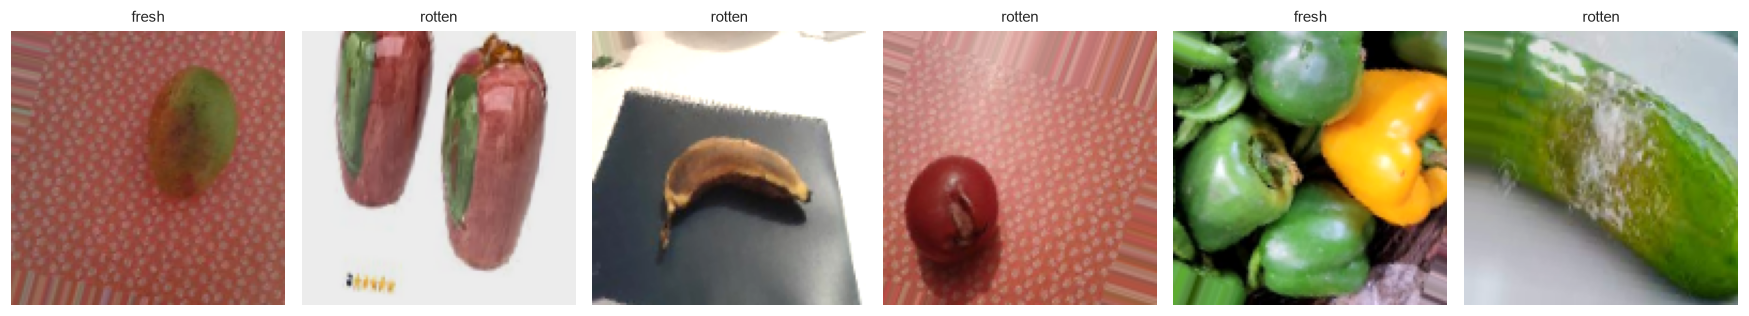

In [6]:
sample_batch_images, sample_batch_labels = next(train_gen)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i in range(6):
    axes[i].imshow(sample_batch_images[i])
    label = "rotten" if sample_batch_labels[i] == 1 else "fresh"
    axes[i].set_title(label, fontsize=10)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("augmentation_preview.png", bbox_inches="tight")
plt.show()


## 5. Baseline CNN Architecture

A compact CNN: three convolution and max pooling blocks that increase in filter depth, followed
by a dense classification head with dropout for regularization. The architecture is wrapped in a
function so the same structure can be reused with different hyperparameters in Section 6.

In [7]:
def build_model(learning_rate=1e-3, dropout_rate=0.3, optimizer_name="adam"):
    model = keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ])

    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return model

baseline_model = build_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,705 (16.36 MB)

 Trainable params: 4,288,257 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

### 5.1 Train the baseline model

In [8]:
BASELINE_EPOCHS = 15

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
)


Epoch 1/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 82s 308ms/step - accuracy: 0.6799 - loss: 0.9302 - val_accuracy: 0.5100 - val_loss: 4.5014
Epoch 2/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 95s 360ms/step - accuracy: 0.7583 - loss: 0.4987 - val_accuracy: 0.8231 - val_loss: 0.3950
Epoch 3/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 102s 386ms/step - accuracy: 0.7995 - loss: 0.4347 - val_accuracy: 0.7414 - val_loss: 0.6095
Epoch 4/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 75s 285ms/step - accuracy: 0.8133 - loss: 0.4213 - val_accuracy: 0.6502 - val_loss: 0.6694
Epoch 5/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 71s 271ms/step - accuracy: 0.8275 - loss: 0.3899 - val_accuracy: 0.8515 - val_loss: 0.3535
Epoch 6/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 272ms/step - accuracy: 0.8293 - loss: 0.3883 - val_accuracy: 0.8593 - val_loss: 0.3269
Epoch 7/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 71s 271ms/step - accuracy: 0.8527 - loss: 0.3493 - val_accuracy: 0.7125 - val_loss: 0.7300
Epoch 8/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 273ms/step - accuracy: 0.8533 - loss: 

### 5.2 Baseline training curves

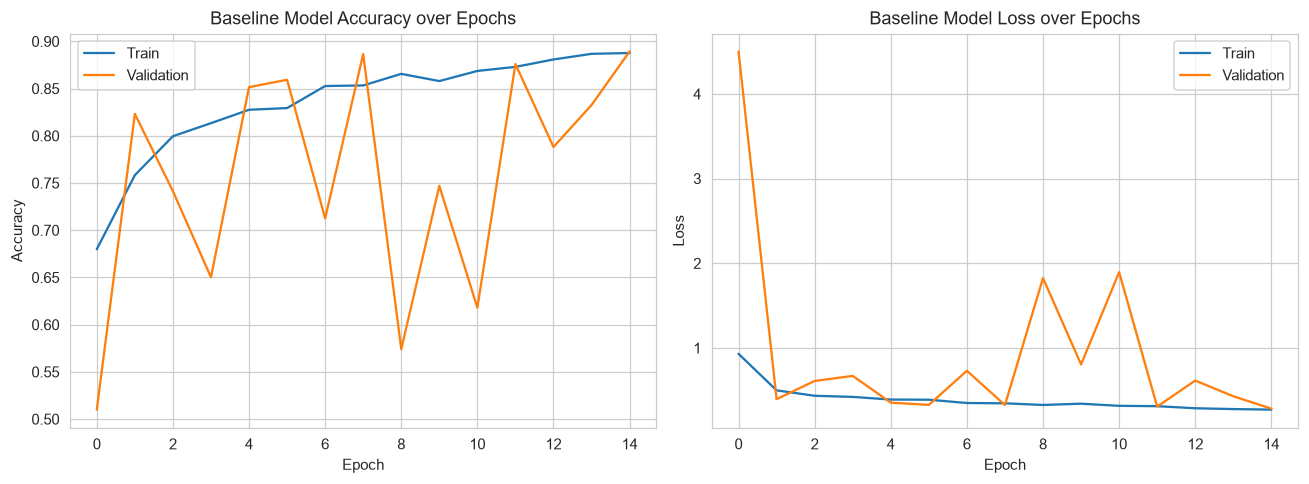

In [9]:
def plot_history(history, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title_prefix}Accuracy over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation")
    axes[1].set_title(f"{title_prefix}Loss over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    plt.tight_layout()
    return fig

fig = plot_history(baseline_history, "Baseline Model ")
plt.savefig("baseline_training_curves.png", bbox_inches="tight")
plt.show()


## 6. Hyperparameter Experiments

A small grid of learning rate, batch size, and optimizer combinations is trained for a shorter
number of epochs each, purely to compare their effect on validation accuracy and loss. The
best performing configuration is then retrained for longer in Section 7.

In [10]:
HYPERPARAM_GRID = [
    {"learning_rate": 1e-3, "batch_size": 32, "optimizer_name": "adam"},
    {"learning_rate": 1e-4, "batch_size": 32, "optimizer_name": "adam"},
    {"learning_rate": 1e-2, "batch_size": 32, "optimizer_name": "sgd"},
    {"learning_rate": 1e-3, "batch_size": 16, "optimizer_name": "adam"},
    {"learning_rate": 1e-3, "batch_size": 32, "optimizer_name": "rmsprop"},
]

SEARCH_EPOCHS = 6
results = []

for i, params in enumerate(HYPERPARAM_GRID):
    print(f"\n--- Configuration {i+1}/{len(HYPERPARAM_GRID)}: {params} ---")
    tf.keras.backend.clear_session()

    tr_gen, va_gen, _ = make_generators(batch_size=params["batch_size"])
    model = build_model(
        learning_rate=params["learning_rate"],
        optimizer_name=params["optimizer_name"],
    )
    history = model.fit(
        tr_gen, validation_data=va_gen, epochs=SEARCH_EPOCHS,
        class_weight=class_weight_dict, verbose=0,
    )

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    results.append({**params, "best_val_accuracy": best_val_acc, "best_val_loss": best_val_loss})
    print(f"Best val accuracy: {best_val_acc:.4f}  |  Best val loss: {best_val_loss:.4f}")

results_df = pd.DataFrame(results).sort_values("best_val_accuracy", ascending=False).reset_index(drop=True)
results_df



--- Configuration 1/5: {'learning_rate': 0.001, 'batch_size': 32, 'optimizer_name': 'adam'} ---

Found 8390 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Best val accuracy: 0.8482  |  Best val loss: 0.3495

--- Configuration 2/5: {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer_name': 'adam'} ---
Found 8390 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Best val accuracy: 0.9071  |  Best val loss: 0.2563

--- Configuration 3/5: {'learning_rate': 0.01, 'batch_size': 32, 'optimizer_name': 'sgd'} ---
Found 8390 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Best val accuracy: 0.7458  |  Best val loss: 0.5512

---

,learning_rate,batch_size,optimizer_name,best_val_accuracy,best_val_loss
0,0.0001,32,adam,0.907119,0.256250
1,0.0010,32,rmsprop,0.857620,0.378729
2,0.0010,32,adam,0.848165,0.349517
3,0.0010,16,adam,0.827586,0.417430
4,0.0100,32,sgd,0.745829,0.551186


### 6.1 Compare configurations

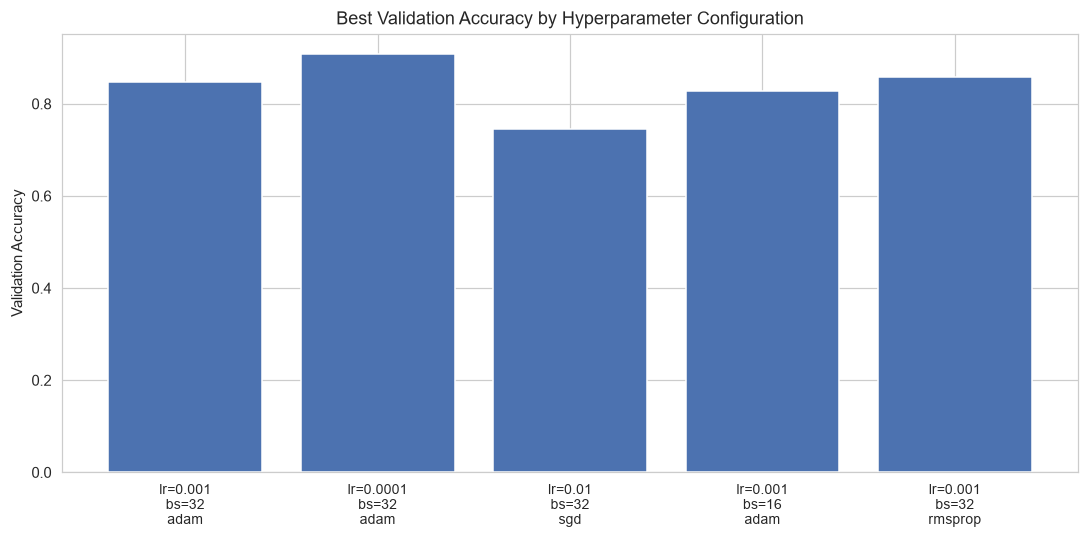

Best configuration: {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer_name': 'adam', 'best_val_accuracy': 0.9071190357208252, 'best_val_loss': 0.25625041127204895}


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"lr={r['learning_rate']}\nbs={r['batch_size']}\n{r['optimizer_name']}" for r in results]
ax.bar(labels, [r["best_val_accuracy"] for r in results], color="#4C72B0")
ax.set_title("Best Validation Accuracy by Hyperparameter Configuration")
ax.set_ylabel("Validation Accuracy")
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("hyperparameter_comparison.png", bbox_inches="tight")
plt.show()

best_config = results_df.iloc[0].to_dict()
print("Best configuration:", best_config)


## 7. Final Model Training

The best configuration found in Section 6 is retrained for more epochs, with early stopping on
validation loss so training does not overfit once performance plateaus.

Found 8390 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Found 1798 validated image filenames belonging to 2 classes.
Epoch 1/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 74s 280ms/step - accuracy: 0.7089 - loss: 0.6033 - val_accuracy: 0.5100 - val_loss: 2.9072 - learning_rate: 1.0000e-04
Epoch 2/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 272ms/step - accuracy: 0.8101 - loss: 0.4184 - val_accuracy: 0.7597 - val_loss: 0.5586 - learning_rate: 1.0000e-04
Epoch 3/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 272ms/step - accuracy: 0.8397 - loss: 0.3671 - val_accuracy: 0.9055 - val_loss: 0.2558 - learning_rate: 1.0000e-04
Epoch 4/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 272ms/step - accuracy: 0.8623 - loss: 0.3195 - val_accuracy: 0.8593 - val_loss: 0.3381 - learning_rate: 1.0000e-04
Epoch 5/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 273ms/step - accuracy: 0.8647 - loss: 0.3139 - val_accuracy: 0.8637 - val_loss: 0.3118 - learning_rate: 1.0000e-04
Epoch 6/25
263/263 ━━━

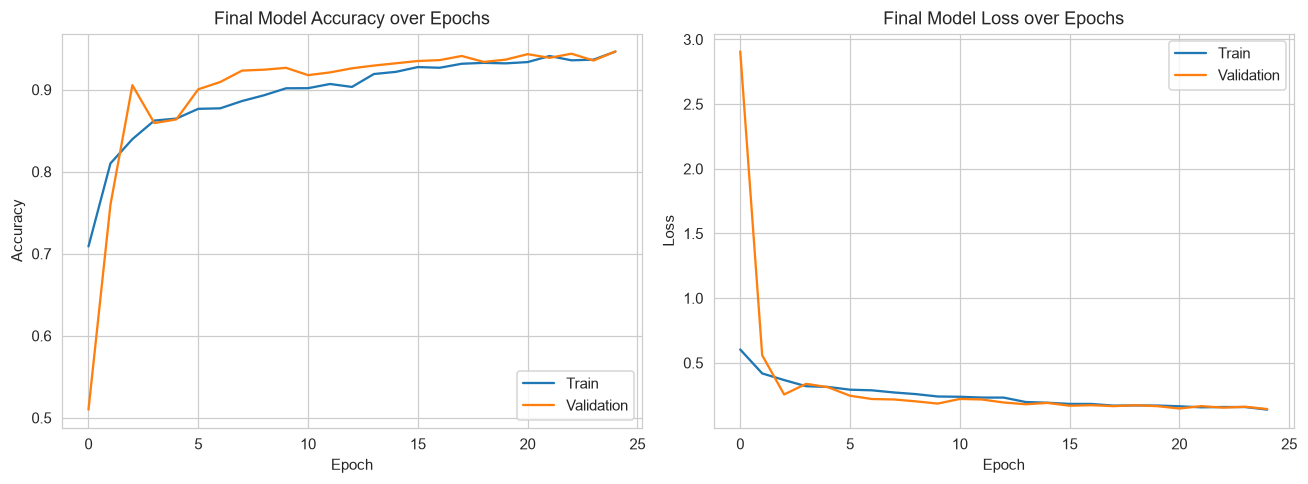

In [12]:
tf.keras.backend.clear_session()

FINAL_EPOCHS = 25
final_batch_size = int(best_config["batch_size"])

final_train_gen, final_val_gen, final_test_gen = make_generators(batch_size=final_batch_size)

final_model = build_model(
    learning_rate=best_config["learning_rate"],
    optimizer_name=best_config["optimizer_name"],
)

final_history = final_model.fit(
    final_train_gen,
    validation_data=final_val_gen,
    epochs=FINAL_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ],
)

fig = plot_history(final_history, "Final Model ")
plt.savefig("final_training_curves.png", bbox_inches="tight")
plt.show()


In [13]:
final_model.save("fruit_veg_freshness_cnn.keras")
print("Model saved to fruit_veg_freshness_cnn.keras")


Model saved to fruit_veg_freshness_cnn.keras


## 8. Evaluation on the Test Set

The final model is evaluated on the held out test set, which it has not seen during training or
hyperparameter search. Metrics: accuracy, precision, recall, F score (per class and weighted
average), a confusion matrix, and an ROC curve with AUC.

In [14]:
test_loss, test_accuracy = final_model.evaluate(final_test_gen, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_true = final_test_gen.classes
y_pred_prob = final_model.predict(final_test_gen).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

class_names = list(final_test_gen.class_indices.keys())  # ["fresh", "rotten"]
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Test loss: 0.1485
Test accuracy: 0.9488
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step

              precision    recall  f1-score   support

       fresh     0.9619    0.9368    0.9492       917
      rotten     0.9359    0.9614    0.9485       881

    accuracy                         0.9488      1798
   macro avg     0.9489    0.9491    0.9488      1798
weighted avg     0.9492    0.9488    0.9488      1798



### 8.1 Confusion matrix

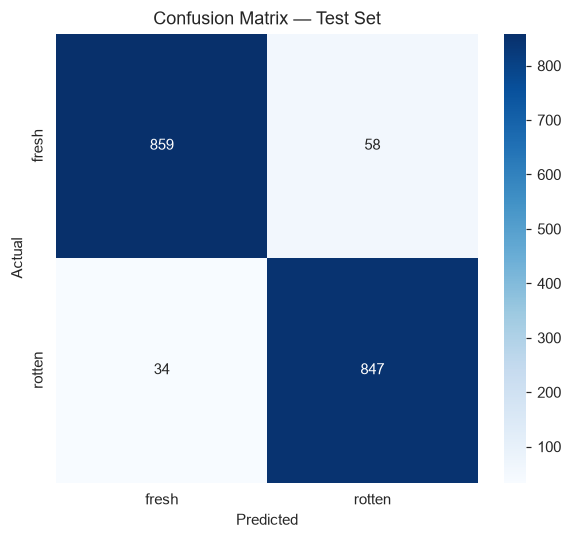

In [15]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()


### 8.2 Precision, recall, and F score by class

In [16]:
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
metrics_df = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support,
})
metrics_df


,class,precision,recall,f1_score,support
0,fresh,0.961926,0.936750,0.949171,917
1,rotten,0.935912,0.961407,0.948488,881


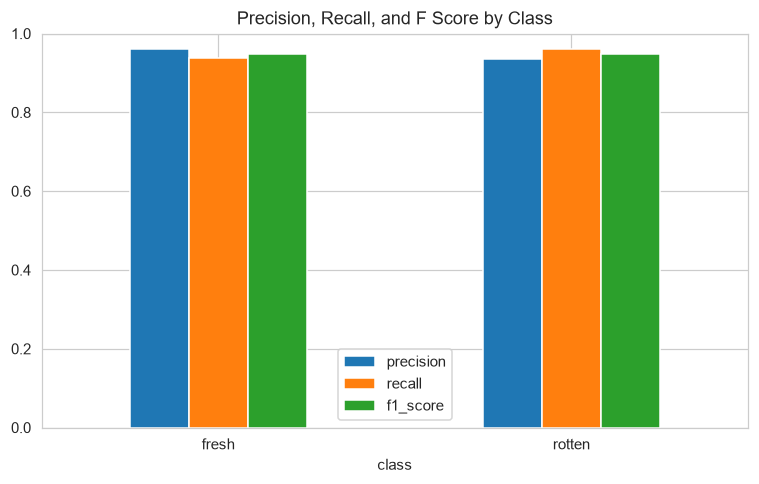

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
metrics_df.set_index("class")[["precision", "recall", "f1_score"]].plot(kind="bar", ax=ax)
ax.set_title("Precision, Recall, and F Score by Class")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("precision_recall_f1.png", bbox_inches="tight")
plt.show()


### 8.3 ROC curve and AUC

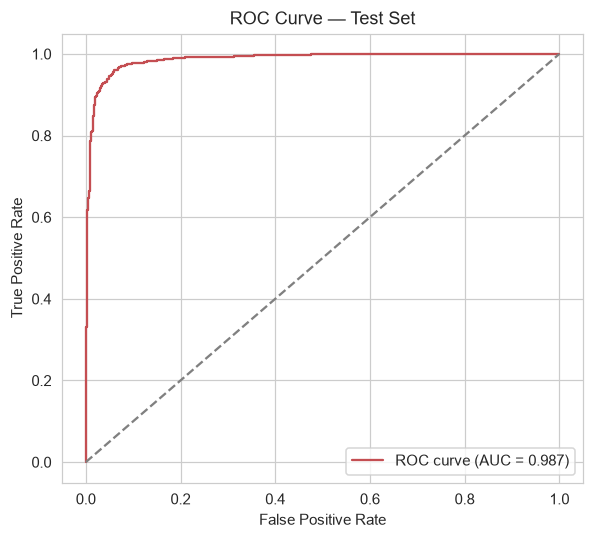

In [18]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="#C44E52", label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()


## 9. Summary of Findings

- **Baseline performance:** *(fill in baseline validation accuracy and loss from Section 5 after
  running)*
- **Effect of hyperparameters:** *(fill in which learning rate, batch size, and optimizer performed
  best in Section 6, and by how much, compared to the others tried)*
- **Final model performance:** *(fill in test accuracy, precision, recall, and F score from Section
  8)*
- **Confusion matrix pattern:** *(fill in which class, fresh or rotten, is more often
  misclassified, and a plausible reason, referencing the background and lighting variability noted
  in the Week 2 EDA)*
- **Next steps:** further tuning (deeper network, transfer learning from a pretrained backbone such
  as MobileNetV2, more aggressive augmentation) could be explored if performance plateaus.

This completes the CNN implementation, hyperparameter tuning, and evaluation required for the Week
4 assignment, building directly on the dataset and preprocessing pipeline established in Week 2.
